In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Step 1: Load dataset
data = pd.read_csv("accidental-deaths-in-usa-monthly.csv")

# Convert Month to datetime and extract features
data['Month'] = pd.to_datetime(data['Month'])
data['Year'] = data['Month'].dt.year
data['Month_num'] = data['Month'].dt.month

X = data[['Year', 'Month_num']]
y = data['Accidental deaths in USA: monthly, 1973 ? 1978']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define criteria
criteria = ["squared_error", "friedman_mse", "absolute_error", "poisson"]

results = {}

for crit in criteria:
    model = DecisionTreeRegressor(criterion=crit, random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[crit] = {"RMSE": rmse, "MAPE": mape, "R²": r2}

# Step 4: Display results
for crit, metrics in results.items():
    print(f"Criterion: {crit}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  MAPE: {metrics['MAPE']:.2%}")
    print(f"  R²: {metrics['R²']:.3f}")
    print("-"*40)

[0.21546893 0.78453107]
[0.21546893 0.78453107]
[0.22883362 0.77116638]
[0.20894914 0.79105086]
Criterion: squared_error
  RMSE: 504.91
  MAPE: 4.37%
  R²: 0.747
----------------------------------------
Criterion: friedman_mse
  RMSE: 504.91
  MAPE: 4.37%
  R²: 0.747
----------------------------------------
Criterion: absolute_error
  RMSE: 673.09
  MAPE: 5.97%
  R²: 0.550
----------------------------------------
Criterion: poisson
  RMSE: 504.91
  MAPE: 4.37%
  R²: 0.747
----------------------------------------


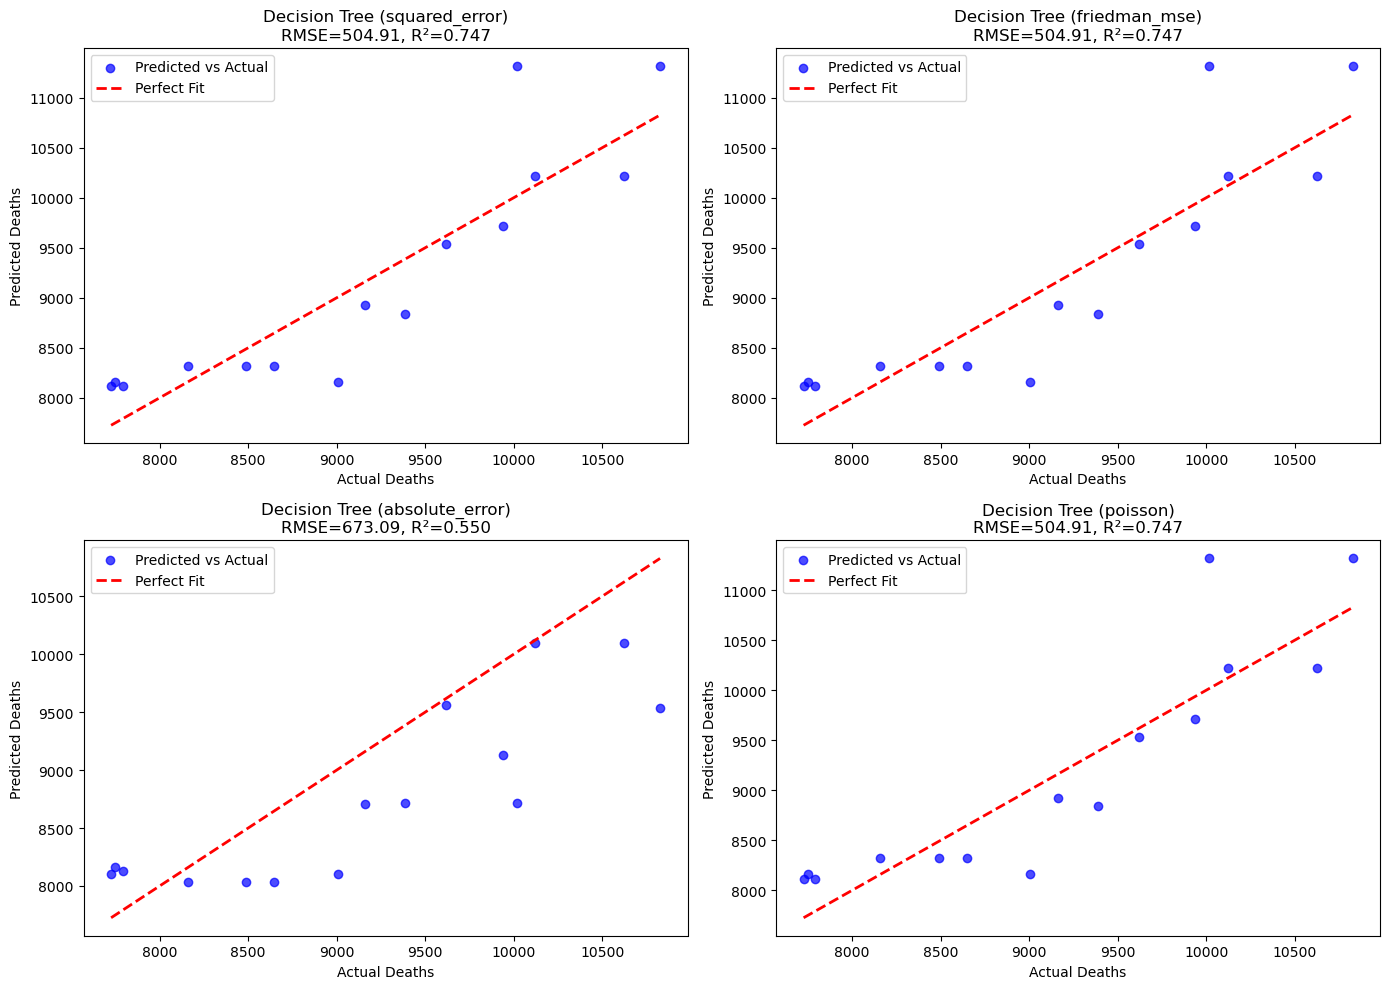

In [4]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for each criterion
plt.figure(figsize=(14, 10))

for i, (crit, metrics) in enumerate(results.items(), 1):
    model = DecisionTreeRegressor(criterion=crit, random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.subplot(2, 2, i)
    plt.scatter(y_test, y_pred, color="blue", alpha=0.7, label="Predicted vs Actual")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label="Perfect Fit")
    plt.xlabel("Actual Deaths")
    plt.ylabel("Predicted Deaths")
    plt.title(f"Decision Tree ({crit})\nRMSE={metrics['RMSE']:.2f}, R²={metrics['R²']:.3f}")
    plt.legend()

plt.tight_layout()
plt.show()

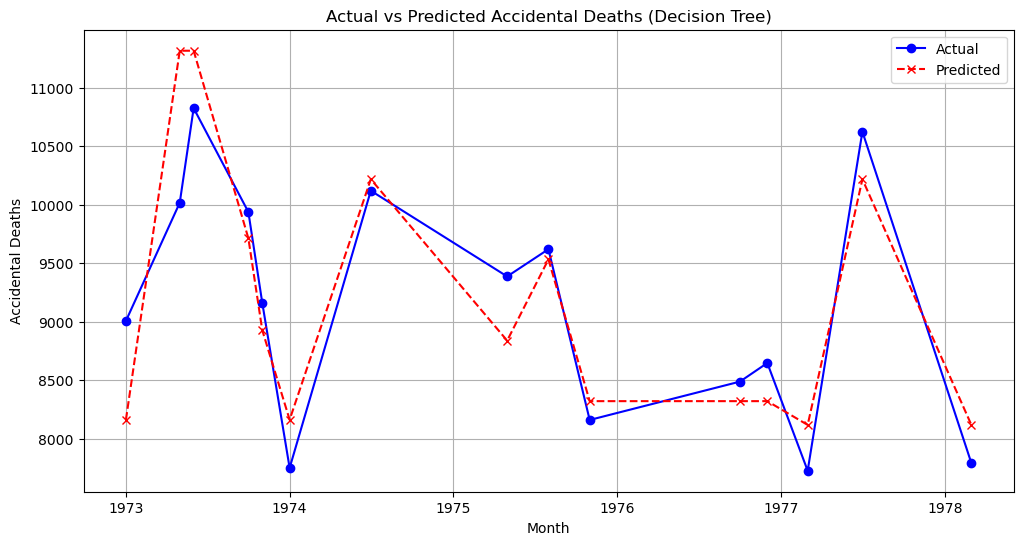

In [5]:
# Combine predictions with test set for plotting
plot_df = X_test.copy()
plot_df['Actual'] = y_test
plot_df['Predicted'] = y_pred
plot_df['Month'] = pd.to_datetime(plot_df['Year'].astype(str) + '-' + plot_df['Month_num'].astype(str))

# Sort by Month for time series plot
plot_df = plot_df.sort_values('Month')

# Plot
plt.figure(figsize=(12,6))
plt.plot(plot_df['Month'], plot_df['Actual'], label="Actual", color="blue", marker="o")
plt.plot(plot_df['Month'], plot_df['Predicted'], label="Predicted", color="red", linestyle="--", marker="x")
plt.xlabel("Month")
plt.ylabel("Accidental Deaths")
plt.title("Actual vs Predicted Accidental Deaths (Decision Tree)")
plt.legend()
plt.grid(True)
plt.show()